[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_GITHUB_USER/YOUR_REPOSITORY/blob/main/YOUR_NOTEBOOK.ipynb)

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

sns.set(style="white")

# ---- Load EFIplus_medit ----
path = "/content/EFIplus_medit.zip"
df = pd.read_csv(path, compression="zip", sep=";")
df.columns = list(map(str, df.columns))

# ---- Filter to Douro and Tejo basins ----
# In this dataset Tagus is typically named "Tejo"
df_bt = df[df["Catchment_name"].isin(["Douro", "Tejo"])].copy()

# ---- Quantitative environmental variables from previous exercises ----
env_vars = [
    "Altitude",
    "Actual_river_slope",
    "Elevation_mean_catch",
    "prec_ann_catch",
    "temp_ann",
    "temp_jan",
    "temp_jul"
]

# Drop rows with missing values in these variables
df_env = df_bt[env_vars].dropna().copy()

# ---- Standardize variables (very important before clustering) ----
scaler = StandardScaler()
X = scaler.fit_transform(df_env.values)
X_df = pd.DataFrame(X, index=df_env.index, columns=env_vars)
X_df.head()

,Altitude,Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul
1,1.977157,0.083440,1.819874,-0.568930,-1.884845,-1.844771,-1.456903
2,1.703876,-0.126266,1.758331,-0.594745,-1.528436,-1.628612,-1.121913
3,1.478000,-0.189680,1.695256,-0.621683,-1.528436,-1.628612,-1.169769
4,1.321839,-0.003937,1.661725,-0.635268,-1.439333,-1.448480,-0.930491
5,1.213084,-0.478288,1.548328,-0.686126,-1.305680,-1.412454,-0.834779


In [2]:
# Pairwise Euclidean distances between sites
dist_sites = pdist(X_df.values, metric="euclidean")

link_methods = ["single", "complete", "average", "ward"]
linkage_mats = {}

for m in link_methods:
    Z = linkage(dist_sites, method=m)
    linkage_mats[m] = Z

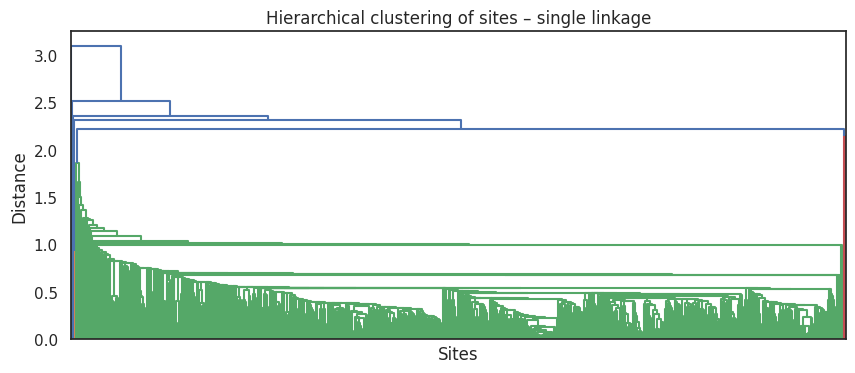

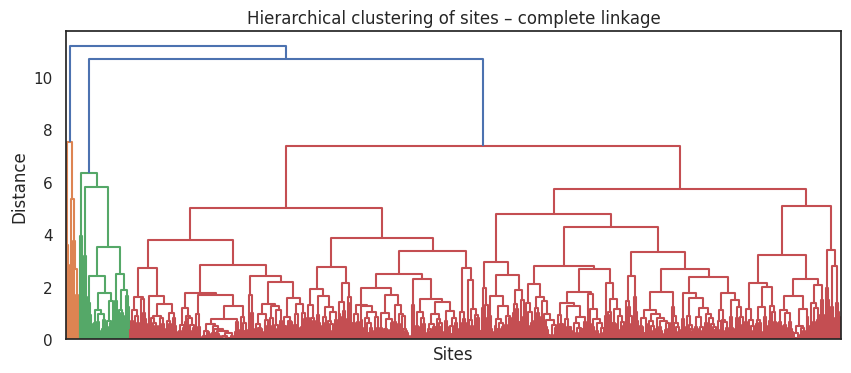

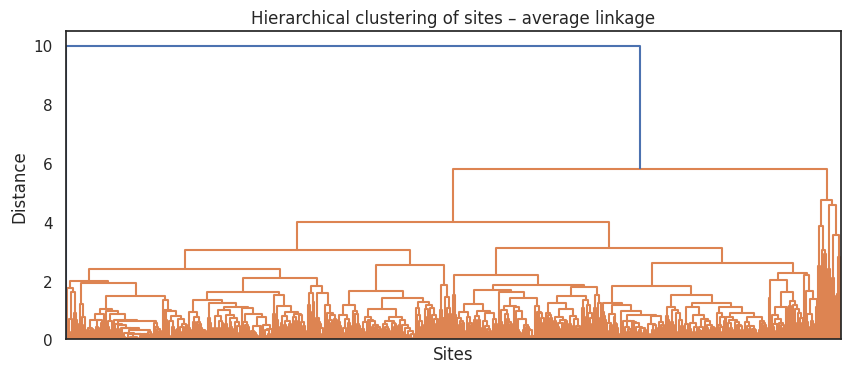

In [3]:
for m in ["single", "complete", "average"]:
    plt.figure(figsize=(10, 4))
    dendrogram(linkage_mats[m], no_labels=True)
    plt.title(f"Hierarchical clustering of sites – {m} linkage")
    plt.xlabel("Sites")
    plt.ylabel("Distance")
    plt.show()

#Across the three linkage methods, single linkage produced long “chains” of sites and is sensitive to nearest‑neighbour noise, complete linkage produced compact but possibly over‑separated clusters, and average linkage offered a balanced structure with coherent site groups and was therefore the most appropriate choice for further analysis.

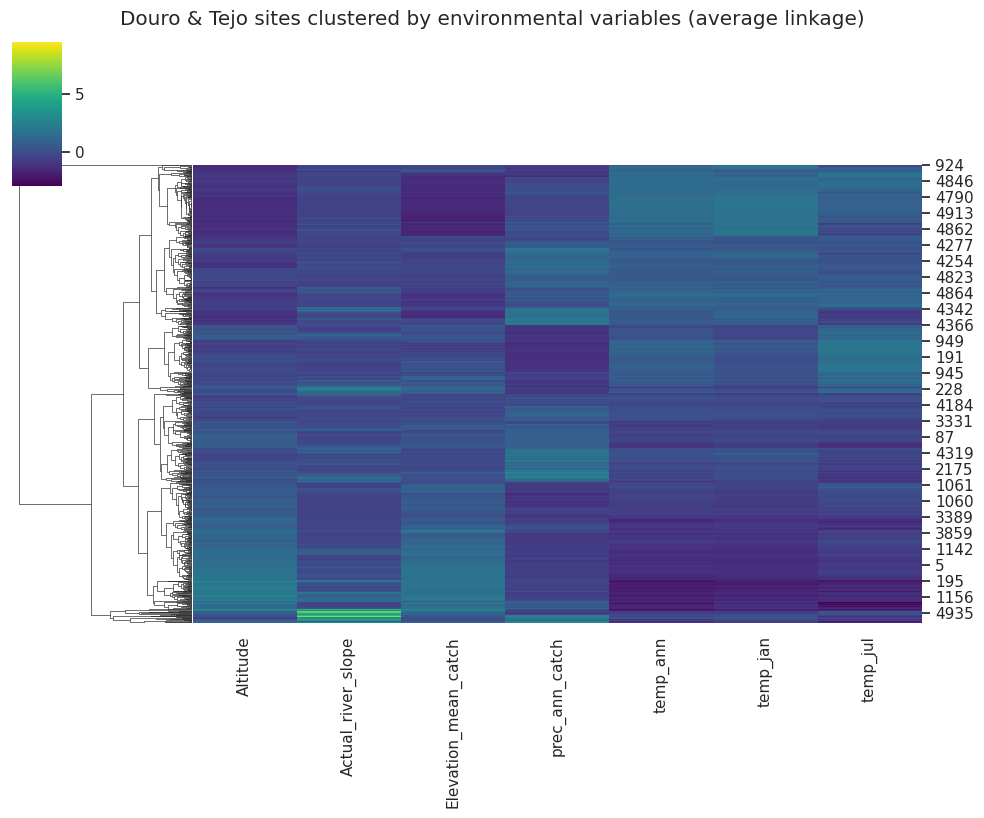

In [4]:
sns.set(style="white")

g = sns.clustermap(
    X_df,                    # standardized env data
    method="average",        # average linkage
    metric="euclidean",
    cmap="viridis",
    row_cluster=True,        # cluster rows (sites)
    col_cluster=False,       # don't cluster columns here
    figsize=(10, 8)
)
plt.suptitle(
    "Douro & Tejo sites clustered by environmental variables (average linkage)",
    y=1.02
)
plt.show()

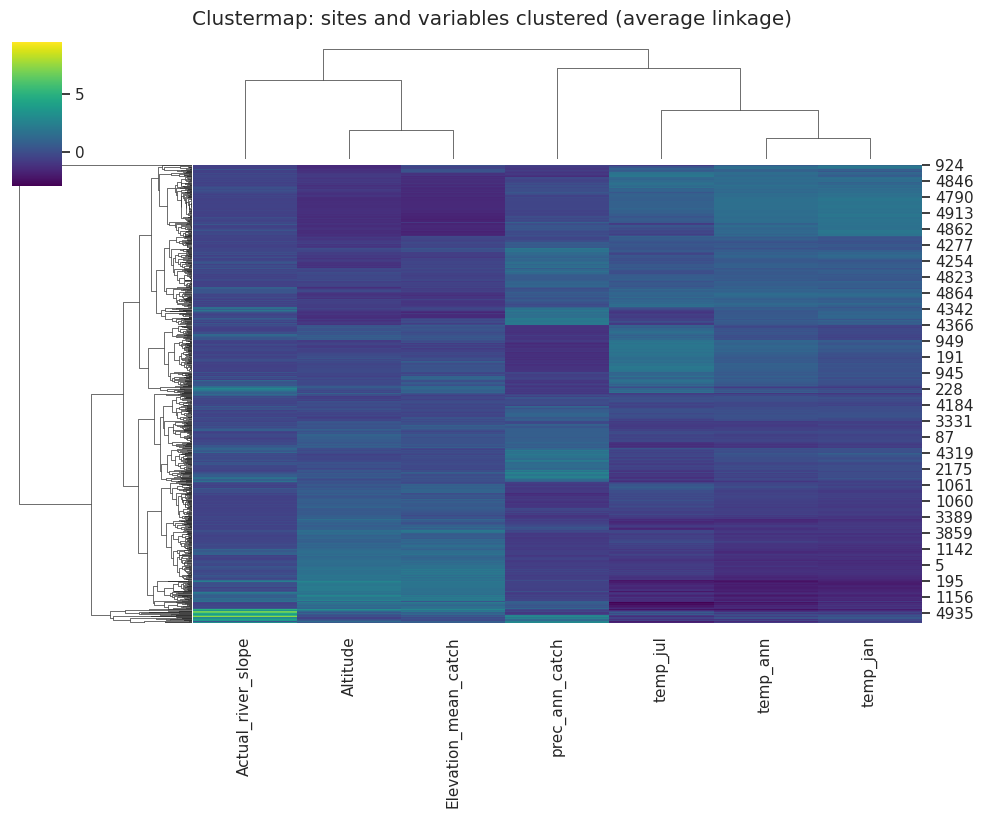

In [5]:
g2 = sns.clustermap(
    X_df,
    method="average",
    metric="euclidean",
    cmap="viridis",
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 8)
)
plt.suptitle("Clustermap: sites and variables clustered (average linkage)", y=1.02)
plt.show()

Sites with similar environmental profiles (temperature, altitude, slope, etc.) appear as blocks of similar colours and are close in the dendrogram.

In [6]:
# Transpose: rows = variables, columns = sites
X_vars = X_df.T   # shape (n_vars, n_sites)

# Distance between variables (based on their standardized values across sites)
dist_vars = pdist(X_vars.values, metric="euclidean")
Z_vars = linkage(dist_vars, method="average")

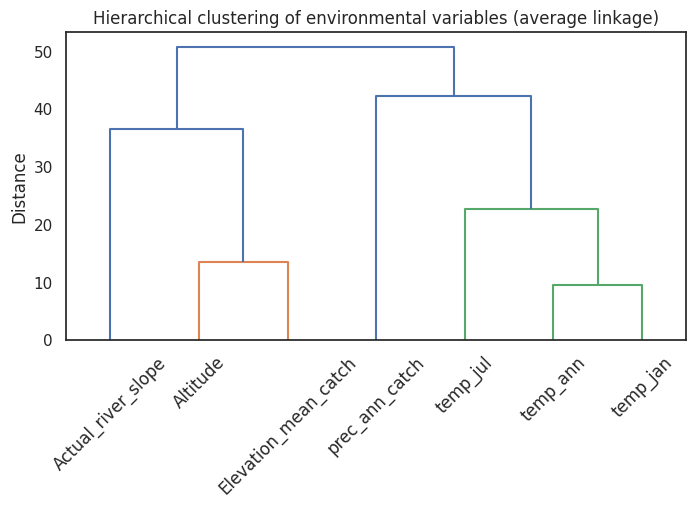

In [7]:
plt.figure(figsize=(8, 4))
dendrogram(
    Z_vars,
    labels=X_vars.index,
    leaf_rotation=45
)
plt.title("Hierarchical clustering of environmental variables (average linkage)")
plt.ylabel("Distance")
plt.show()

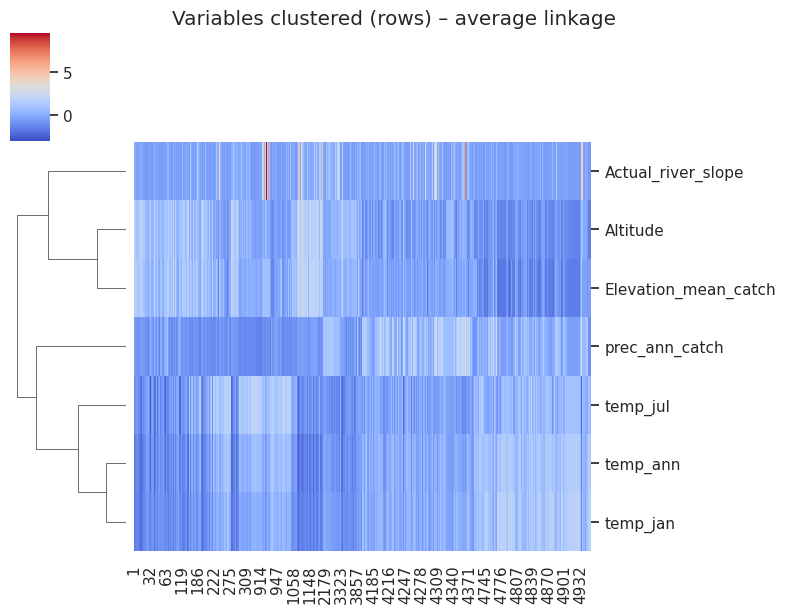

In [8]:
sns.clustermap(
    X_vars,              # variables × sites
    method="average",
    metric="euclidean",
    cmap="coolwarm",
    row_cluster=True,
    col_cluster=False,
    figsize=(8, 6)
)
plt.suptitle("Variables clustered (rows) – average linkage", y=1.02)
plt.show()

#Variables that join the dendrogram at very small distances form tight clusters (e.g. temp_ann, temp_jan, temp_jul are likely in a temperature cluster; Altitude and Elevation_mean_catch often cluster together).

#Within each tight cluster, variables convey similar information, so including all of them in a regression model may lead to multicollinearity and redundant predictors.